# Régression Logistique avec Numpy

Implémentation from scratch d'une régression logistique entraînée par descente de gradient, sur le dataset public **Palmer Penguins** (via seaborn).

Ce notebook est le pendant du notebook de régression linéaire : même dataset, même squelette (modèle, coût, gradient, descente de gradient), mais une **classification** au lieu d'une régression. On ne prédit plus un nombre, on prédit une **probabilité d'appartenir à une classe**.

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.linear_model import LogisticRegression

# rend les figures Plotly visibles dans VS Code / JupyterLab (mimetype) comme dans
# Jupyter Notebook classique (plotly.js chargé depuis le CDN)
pio.renderers.default = 'plotly_mimetype+notebook_connected'

# 1. Dataset
On garde les manchots, mais on change de question : **à quelle espèce appartient ce manchot ?**

On ne garde que deux espèces, Adélie et Chinstrap, pour avoir une classification **binaire** :

- $x$ : `bill_length_mm`, la longueur du bec (en mm)
- $y$ : 1 si le manchot est un Chinstrap, 0 si c'est un Adélie

C'est la convention en classification binaire : la classe qu'on cherche à détecter vaut 1 (la classe « positive »), l'autre vaut 0.

In [3]:
df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
df = df[df['species'].isin(['Adelie', 'Chinstrap'])]
df = df.dropna(subset=['bill_length_mm'])

x = df[['bill_length_mm']].values                    # tableau 2D de dimension (m, 1)
y = (df['species'] == 'Chinstrap').astype(float).values # 1 = Chinstrap, 0 = Adelie

print(df['species'].value_counts())
print('Longueur moyenne du bec par espèce :')
print(df.groupby('species')['bill_length_mm'].mean().round(1))

species
Adelie       151
Chinstrap     68
Name: count, dtype: int64
Longueur moyenne du bec par espèce :
species
Adelie       38.8
Chinstrap    48.8
Name: bill_length_mm, dtype: float64


Visualisons les données. Contrairement à la régression, y ne prend que deux valeurs : tous les points sont écrasés sur deux lignes horizontales (0 et 1). On ajoute un peu de transparence pour voir la densité.

([<matplotlib.axis.YTick at 0x11bb0e990>,
 [Text(0, 0, '0'), Text(0, 1, '1')])

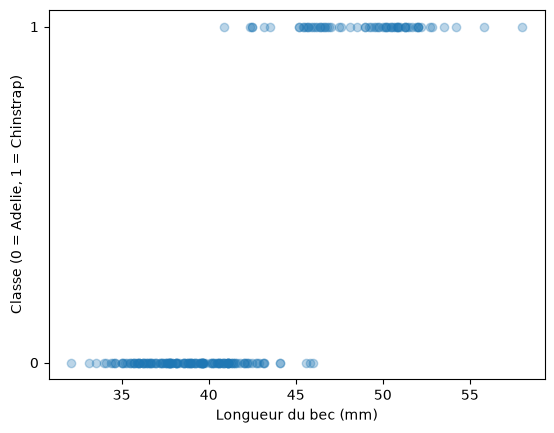

In [3]:
plt.scatter(x, y, alpha=0.3)
plt.xlabel('Longueur du bec (mm)')
plt.ylabel('Classe (0 = Adelie, 1 = Chinstrap)')
plt.yticks([0, 1])

On voit déjà la logique du problème : les becs courts (moins de 42 mm environ) sont des Adélie, les becs longs (plus de 46 mm) sont des Chinstrap, et entre les deux il y a une **zone de recouvrement** où les deux espèces coexistent. Aucun modèle ne pourra classer ces manchots-là sans erreur.

Comme pour la régression linéaire, on vérifie les dimensions et on redimensionne y.

In [4]:
print(x.shape)
print(y.shape)

# redimensionner y
y = y.reshape(y.shape[0], 1)

print(y.shape)

(219, 1)
(219,)
(219, 1)


Création de la matrice $X$ avec la colonne de biais, et du vecteur paramètre $\theta$ (pente, biais), exactement comme en régression linéaire.

In [5]:
X_brut = np.hstack((x, np.ones(x.shape)))
print(X_brut.shape)

np.random.seed(0) # pour produire toujours le même vecteur theta aléatoire
theta = np.random.randn(2, 1)
theta

(219, 2)


array([[1.76405235],
       [0.40015721]])

# 2. Modèle logistique
En régression linéaire, le modèle était $X.\theta$, qui peut valoir n'importe quel nombre entre $-\infty$ et $+\infty$. Ici on veut une **probabilité**, donc un nombre entre 0 et 1.

On garde donc $X.\theta$, et on l'écrase entre 0 et 1 avec la fonction **sigmoïde** :

$ \sigma(z) = \frac{1}{1 + e^{-z}} \qquad \text{et} \qquad A = \sigma(X.\theta) $

$A$ (pour « activation ») est la probabilité prédite que le manchot soit un Chinstrap.

Text(0.5, 1.0, 'La sigmoïde écrase tout entre 0 et 1')

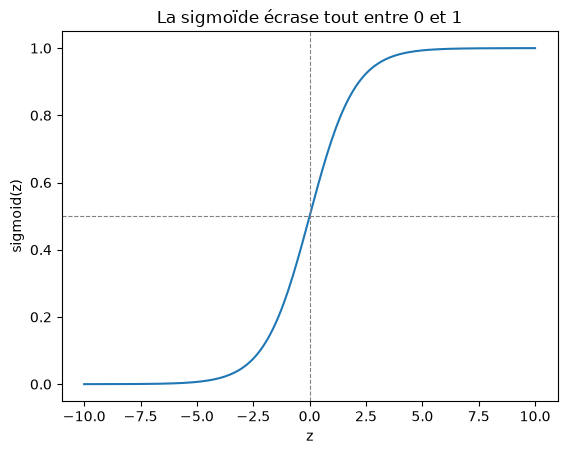

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# à quoi ressemble la sigmoïde ?
z = np.linspace(-10, 10, 200)
plt.plot(z, sigmoid(z))
plt.axhline(0.5, color='grey', linewidth=0.8, linestyle='--')
plt.axvline(0, color='grey', linewidth=0.8, linestyle='--')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('La sigmoïde écrase tout entre 0 et 1')

Points à retenir sur la sigmoïde :

- quand $z$ est très négatif, $\sigma(z)$ tend vers 0 ; quand $z$ est très positif, elle tend vers 1
- quand $z = 0$, $\sigma(z) = 0.5$ : c'est la **frontière de décision**, le point où le modèle hésite à parts égales

On implémente le modèle, puis on le teste avec le $\theta$ aléatoire (bonne pratique oblige).

Le résultat a l'air étrange : la courbe rouge est collée à 1, le modèle prédit « Chinstrap à 100 % » pour tous les manchots. C'est normal ici : les becs valent environ 45, donc $X.\theta$ vaut déjà plusieurs dizaines, et la sigmoïde renvoie 1. Retenez cette image, on y revient en 5.1.


In [7]:
def model(X, theta):
    return sigmoid(X.dot(theta))

Text(0.5, 1.0, 'Le modèle initial, avec theta aléatoire')

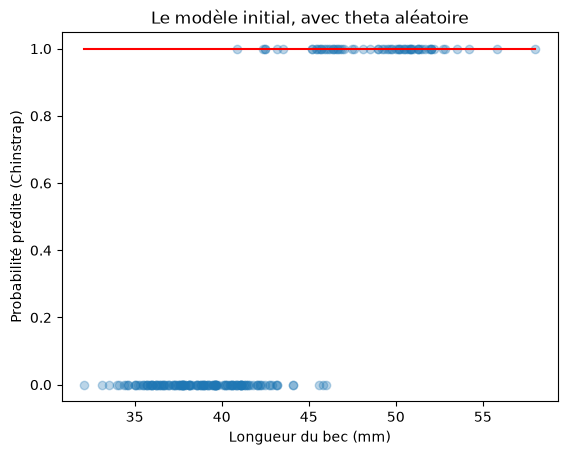

In [8]:
# on trie x pour tracer une courbe propre
ordre = x.ravel().argsort()

plt.scatter(x, y, alpha=0.3)
plt.plot(x[ordre], model(X_brut, theta)[ordre], c='r')
plt.xlabel('Longueur du bec (mm)')
plt.ylabel('Probabilité prédite (Chinstrap)')
plt.title('Le modèle initial, avec theta aléatoire')

# 3. Fonction coût : log loss
En régression linéaire, on utilisait la MSE. Ici elle ne convient pas : combinée à la sigmoïde, elle donne une fonction avec plusieurs minimums locaux, dans laquelle la descente de gradient peut rester coincée.

On utilise donc la **log loss** (ou entropie croisée binaire) :

$ J(\theta) = -\frac{1}{m} \sum \left[ y \log(A) + (1 - y) \log(1 - A) \right] $

Elle se lit simplement, en regardant un manchot à la fois :

- si $y = 1$, seul le terme $\log(A)$ compte : le coût est nul si le modèle a prédit $A = 1$, et il tend vers l'infini si le modèle a prédit $A = 0$
- si $y = 0$, c'est le terme $\log(1 - A)$ qui joue, de façon symétrique

Autrement dit, **plus le modèle est sûr de lui et se trompe, plus il est puni**. Le `epsilon` dans le code évite un $\log(0)$, qui vaudrait $-\infty$.

In [9]:
def cost_function(X, y, theta):
    m = len(y)
    A = model(X, theta)
    epsilon = 1e-15 # évite log(0)
    return -1/m * np.sum(y * np.log(A + epsilon) + (1 - y) * np.log(1 - A + epsilon))

In [10]:
cost_function(X_brut, y, theta)

np.float64(23.81440746863704)

# 4. Gradient et descente de gradient
Voici la bonne surprise : malgré la sigmoïde et la nouvelle fonction coût, le gradient a **exactement la même forme** qu'en régression linéaire :

$ \frac{\partial J(\theta)}{\partial \theta} = \frac{1}{m} X^T.(A - y) $

Ce n'est pas un hasard : la log loss a été choisie en partie parce qu'elle donne ce gradient simple. La seule différence avec la régression linéaire, c'est que $A$ passe par la sigmoïde.

La descente de gradient, elle, ne change pas d'un iota : $\theta = \theta - \alpha \frac{\partial J(\theta)}{\partial \theta}$

In [11]:
def grad(X, y, theta):
    m = len(y)
    return 1/m * X.T.dot(model(X, theta) - y)

In [12]:
def gradient_descent(X, y, theta, learning_rate, n_iterations):
    
    cost_history = np.zeros(n_iterations)  # évolution du coût
    theta_history = np.zeros((n_iterations, theta.shape[0]))  # évolution des paramètres
    
    for i in range(0, n_iterations):
        theta = theta - learning_rate * grad(X, y, theta)
        cost_history[i] = cost_function(X, y, theta)
        theta_history[i] = theta.ravel()
        
    return theta, cost_history, theta_history

# 5. Phase d'entraînement
## 5.1 Premier essai : x dans ses unités d'origine
Comme en régression linéaire, on commence par lancer la descente de gradient sur `X_brut`, avec des becs qui mesurent environ 45 mm.

In [13]:
n_iterations = 1000
learning_rate = 0.5

with np.errstate(over='ignore'): # masque les avertissements de la sigmoïde (exp de très grands nombres)
    theta_brut, cost_history_brut, theta_history_brut = gradient_descent(X_brut, y, theta, learning_rate, n_iterations)

print('Coût aux 6 premières itérations :', cost_history_brut[:6].round(2))
print('Theta final :', theta_brut.ravel().round(2))

Coût aux 6 premières itérations : [10.72 10.72 23.81 10.72 10.72 23.81]
Theta final : [ -8.1 -25.3]


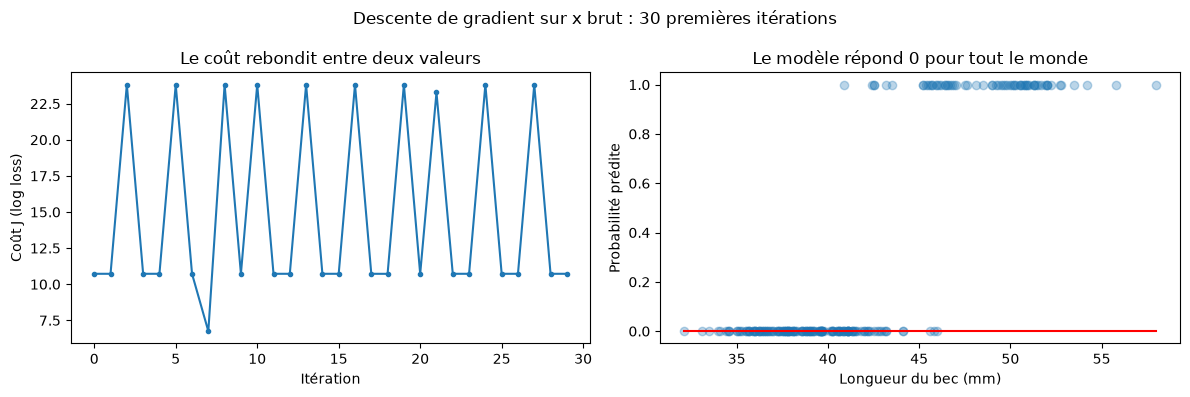

In [14]:
n_zoom = 30 # le motif se répète ensuite à l'identique

figure, (gauche, droite) = plt.subplots(1, 2, figsize=(12, 4))

gauche.plot(range(n_zoom), cost_history_brut[:n_zoom], marker='.')
gauche.set_xlabel('Itération')
gauche.set_ylabel('Coût J (log loss)')
gauche.set_title('Le coût rebondit entre deux valeurs')

droite.scatter(x, y, alpha=0.3)
droite.plot(x[ordre], model(X_brut, theta_brut)[ordre], c='r')
droite.set_xlabel('Longueur du bec (mm)')
droite.set_ylabel('Probabilité prédite')
droite.set_title('Le modèle répond 0 pour tout le monde')

figure.suptitle(f'Descente de gradient sur x brut : {n_zoom} premières itérations')
plt.tight_layout()

**Le modèle n'apprend rien.** Le coût ne descend pas : il **oscille sans fin** entre deux niveaux, 10,72 et 23,81 (avec, de loin en loin, un point intermédiaire), et cela pendant les 1000 itérations. La courbe de droite le confirme : le modèle final répond « 0 % de chances d'être un Chinstrap » pour tous les manchots, y compris les Chinstrap.

Ces deux valeurs ne sont pas mystérieuses :

- **10,72**, c'est le coût d'un modèle qui répond 0 pour tout le monde, avec une certitude absolue
- **23,81**, c'est le coût d'un modèle qui répond 1 pour tout le monde

Le modèle fait donc l'aller-retour entre « tous Adélie » et « tous Chinstrap », sans jamais rien apprendre entre les deux.

**Pourquoi ?** Les becs mesurent environ 45 mm, donc dès le premier pas, $X.\theta$ atteint des valeurs énormes. La sigmoïde **sature** : elle renvoie exactement 0 ou exactement 1 (c'est d'ailleurs ce qui provoque l'avertissement de débordement de `np.exp`, qu'on a masqué). Or si $A$ vaut toujours 0 ou 1, le gradient $\frac{1}{m}X^T(A - y)$ ne prend plus que deux valeurs possibles, et il ne dit plus rien sur la direction à prendre. La descente de gradient tourne en rond.

C'est le contraire de ce qu'on observait en régression linéaire, où un pas trop grand faisait exploser le modèle en `nan`. Ici, rien n'explose, car la sigmoïde borne l'erreur $A - y$ entre -1 et 1. Le modèle se bloque au lieu de diverger, mais le remède est le même : **standardiser x**.

## 5.2 La solution : standardiser x
On centre et on réduit x : $x_{std} = \frac{x - \bar{x}}{\sigma_x}$. On garde x d'origine pour les graphiques.

In [15]:
x_std = (x - x.mean()) / x.std()
print(x_std.mean().round(3), x_std.std().round(3))

X = np.hstack((x_std, np.ones(x_std.shape)))
print(X.shape)

-0.0 1.0
(219, 2)


In [16]:
theta_final, cost_history, theta_history = gradient_descent(X, y, theta, learning_rate, n_iterations)

print('Coût final  :', cost_history[-1].round(4))
print('Theta final :', theta_final.ravel().round(3))

Coût final  : 0.1154
Theta final : [ 5.548 -2.224]


Text(0.5, 1.0, 'Modèle entraîné sur x standardisé')

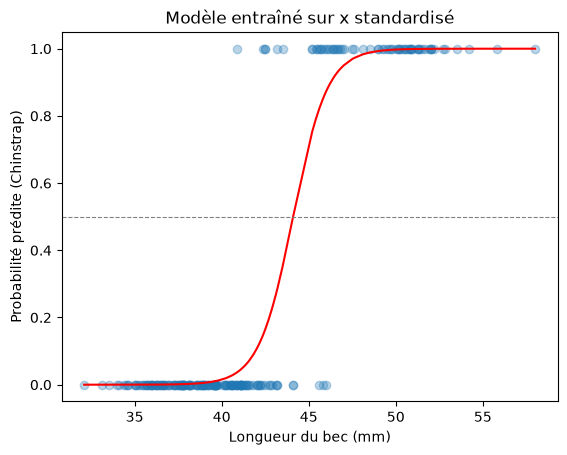

In [17]:
# les probabilités prédites par le modèle final
probabilites = model(X, theta_final)

plt.scatter(x, y, alpha=0.3)
plt.plot(x[ordre], probabilites[ordre], c='r')
plt.axhline(0.5, color='grey', linewidth=0.8, linestyle='--')
plt.xlabel('Longueur du bec (mm)')
plt.ylabel('Probabilité prédite (Chinstrap)')
plt.title('Modèle entraîné sur x standardisé')

Cette fois la sigmoïde est bien placée : elle vaut presque 0 sur les becs courts, presque 1 sur les becs longs, et elle bascule dans la zone de recouvrement.

## 5.3 Voir la sigmoïde se mettre en place, itération par itération
Comme en régression linéaire, on rejoue tout l'entraînement avec `theta_history`. Au lieu d'une droite qui pivote, c'est ici une sigmoïde qui se redresse et se déplace.

In [18]:
# itérations à afficher : fines au début (tout bouge), larges ensuite (plus rien ne bouge)
iterations_affichees = list(range(0, 50, 2)) + list(range(50, n_iterations, 25)) + [n_iterations - 1]

# grille de becs pour tracer une courbe lisse
x_grille = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
x_grille_std = (x_grille - x.mean()) / x.std()
X_grille = np.hstack((x_grille_std, np.ones(x_grille_std.shape)))

def courbe(i):
    """Trace de la sigmoïde du modèle telle qu'elle est à l'itération i."""
    return go.Scatter(
        x=x_grille.ravel(),
        y=model(X_grille, theta_history[i].reshape(-1, 1)).ravel(),
        mode='lines', line=dict(color='red', width=3), name='Probabilité prédite',
    )

def titre(i):
    t0, t1 = theta_history[i]
    return (f'Itération {i}   |   θ₀ (pente) = {t0:.2f}   |   '
            f'θ₁ (biais) = {t1:.2f}   |   coût J = {cost_history[i]:.3f}')

nuage = go.Scatter(x=x.ravel(), y=y.ravel(), mode='markers',
                   marker=dict(size=6, color='steelblue', opacity=0.4), name='Manchots')

fig = go.Figure(
    data=[nuage, courbe(0)],
    # traces=[1] : seule la sigmoïde (index 1) est redessinée à chaque frame,
    # le nuage de points (index 0) reste en place.
    frames=[go.Frame(data=[courbe(i)], traces=[1], name=str(i),
                     layout=go.Layout(title=titre(i)))
            for i in iterations_affichees],
)

fig.add_hline(y=0.5, line_dash='dash', line_color='grey')

fig.update_layout(
    title=titre(iterations_affichees[0]),
    xaxis_title='Longueur du bec (mm)',
    yaxis_title='Probabilité prédite (Chinstrap)',
    yaxis_range=[-0.1, 1.1],
    width=800, height=550,
    updatemenus=[dict(
        type='buttons',
        buttons=[
            dict(label='Play', method='animate',
                 args=[None, {'frame': {'duration': 120, 'redraw': True}, 'fromcurrent': True}]),
            dict(label='Pause', method='animate',
                 args=[[None], {'frame': {'duration': 0}, 'mode': 'immediate'}]),
        ],
    )],
    sliders=[dict(
        currentvalue={'prefix': 'Itération : '},
        steps=[dict(method='animate', label=str(i),
                    args=[[str(i)], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}])
               for i in iterations_affichees],
    )],
)

fig.show()

Ce qu'on observe en appuyant sur **Play** :

- la courbe part d'une position aléatoire, et **se déplace d'abord latéralement** : le modèle cherche **où** poser la frontière. Elle passe de 41 mm à 44,2 mm en une cinquantaine d'itérations, puis ne bouge quasiment plus
- ensuite, pendant les 950 itérations restantes, elle **se redresse** sur place : $\theta_0$ continue de grandir (de 3 à 5,5), donc la transition entre 0 et 1 devient de plus en plus nette. Le modèle devient plus catégorique, sans changer d'avis sur la frontière
- elle ne devient jamais complètement verticale, et c'est normal : les deux espèces se recouvrent autour de 44 mm, donc le modèle a intérêt à rester prudent dans cette zone

# 6. Courbe d'apprentissage
On vérifie que la descente de gradient a bien fonctionné en traçant l'évolution du coût.

Text(0, 0.5, 'Coût J (log loss)')

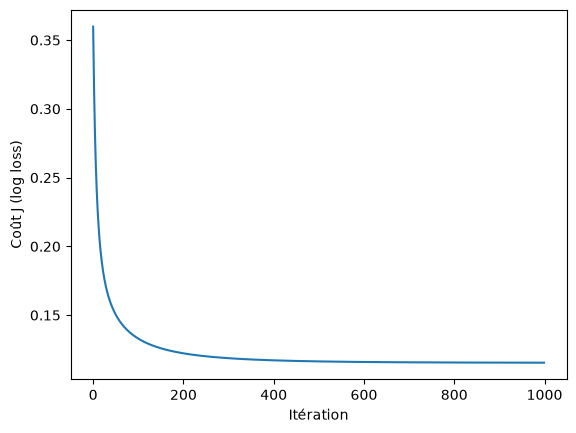

In [19]:
plt.plot(range(n_iterations), cost_history)
plt.xlabel('Itération')
plt.ylabel('Coût J (log loss)')

La courbe descend puis s'aplatit autour de 0,12, très loin des 0,7 obtenus sur x brut. Comme en régression, ce minimum n'est pas zéro : à cause de la zone de recouvrement, aucun modèle ne peut être certain pour tous les manchots.

# 7. Interpréter et vérifier le modèle
## 7.1 Revenir aux unités réelles
$\theta$ a été appris sur x standardisé. On le reconvertit comme en régression linéaire :

In [20]:
pente = theta_final[0, 0] / x.std()
biais = theta_final[1, 0] - pente * x.mean()

print(f'Pente : {pente:.3f} par mm de bec')
print(f'Biais : {biais:.2f}')

# frontière de décision : le bec pour lequel le modèle prédit exactement 0.5
seuil_mm = -biais / pente
print(f'\nFrontière de décision : {seuil_mm:.1f} mm')

Pente : 1.015 par mm de bec
Biais : -44.77

Frontière de décision : 44.1 mm


Deux lectures possibles de ce modèle :

- **La frontière** : au-delà d'environ 44 mm de bec, le modèle parie Chinstrap ; en dessous, il parie Adélie. C'est ce qu'on obtient en résolvant $\theta_0 x + \theta_1 = 0$, c'est-à-dire le point où la sigmoïde passe par 0,5.
- **La pente** : contrairement à la régression linéaire, elle ne se lit pas en « unités de y par mm ». Elle agit sur le **log des cotes** (log odds). Un millimètre de bec en plus multiplie la cote Chinstrap / Adélie par $e^{\theta_0}$.

In [21]:
print(f'Un mm de bec en plus multiplie la cote (Chinstrap / Adelie) par {np.exp(pente):.2f}')

Un mm de bec en plus multiplie la cote (Chinstrap / Adelie) par 2.76


## 7.2 Vérifier avec scikit-learn
On compare avec `LogisticRegression`. Attention : par défaut scikit-learn applique une **régularisation** (il bride les coefficients pour éviter le surapprentissage), ce que notre code ne fait pas. Pour comparer ce qui est comparable, on la neutralise avec un `C` très grand.

In [22]:
reference = LogisticRegression(C=1e6).fit(x, y.ravel())

print(f'Notre modèle : pente = {pente:.3f}, frontière = {seuil_mm:.2f} mm')
print(f'scikit-learn : pente = {reference.coef_[0, 0]:.3f}, '
      f'frontière = {-reference.intercept_[0] / reference.coef_[0, 0]:.2f} mm')

Notre modèle : pente = 1.015, frontière = 44.10 mm
scikit-learn : pente = 1.049, frontière = 44.09 mm


Les frontières de décision coïncident au dixième de millimètre : notre implémentation est correcte.

Les pentes, elles, diffèrent un peu. Notre descente de gradient n'a pas tout à fait fini de converger après 1000 itérations : elle continuerait à redresser la sigmoïde si on la laissait tourner. Cela ne change presque rien aux prédictions, car ce qui compte pour classer, c'est la position de la frontière.

# 8. Évaluation finale
## 8.1 Du score à la décision
Le modèle sort des probabilités. Pour décider d'une classe, il faut choisir un **seuil**, classiquement 0,5.

In [23]:
predictions = probabilites >= 0.5 # True = Chinstrap
predictions[:10].ravel()

array([False, False, False, False, False, False, False, False, False,
       False])

In [24]:
def accuracy(y, pred):
    return (pred == (y == 1)).mean()

accuracy(y, predictions)

np.float64(0.958904109589041)

## 8.2 Regarder les erreurs en détail
Le taux de bonnes réponses (accuracy) cache la nature des erreurs. On construit la **matrice de confusion** à la main : elle compte les quatre cas possibles.

In [25]:
vrai_positif = int(((predictions == True) & (y == 1)).sum())   # Chinstrap bien identifiés
vrai_negatif = int(((predictions == False) & (y == 0)).sum())  # Adelie bien identifiés
faux_positif = int(((predictions == True) & (y == 0)).sum())   # Adelie pris pour des Chinstrap
faux_negatif = int(((predictions == False) & (y == 1)).sum())  # Chinstrap ratés

print(f'Chinstrap bien identifiés (vrais positifs) : {vrai_positif}')
print(f'Adelie bien identifiés (vrais négatifs)    : {vrai_negatif}')
print(f'Adelie pris pour des Chinstrap (faux positifs) : {faux_positif}')
print(f'Chinstrap ratés (faux négatifs)                : {faux_negatif}')

Chinstrap bien identifiés (vrais positifs) : 62
Adelie bien identifiés (vrais négatifs)    : 148
Adelie pris pour des Chinstrap (faux positifs) : 3
Chinstrap ratés (faux négatifs)                : 6


**Deux précautions à garder en tête :**

- Les classes sont **déséquilibrées** : il y a 151 Adélie pour 68 Chinstrap. Un modèle bête qui répondrait toujours « Adélie » obtiendrait déjà 69 % de bonnes réponses. C'est à ce chiffre-là qu'il faut comparer notre accuracy, pas à 50 %.
- Ces scores sont calculés sur les **données d'entraînement**, ils sont donc optimistes. Pour mesurer la performance sur de nouveaux manchots, et pour choisir les bonnes métriques (précision, rappel, F1), voir le TP 01.

# 9. Le seuil est un choix, pas une vérité
Le seuil de 0,5 n'a rien d'obligatoire. Le déplacer change la nature des erreurs : un seuil bas attrape plus de Chinstrap mais se trompe plus souvent sur les Adélie, et inversement.

In [26]:
print(f'{"Seuil":>8} {"Chinstrap ratés":>18} {"Adelie mal classés":>20} {"Accuracy":>10}')
for seuil in [0.2, 0.35, 0.5, 0.65, 0.8]:
    pred_seuil = probabilites >= seuil
    rates = int(((pred_seuil == False) & (y == 1)).sum())
    faux = int(((pred_seuil == True) & (y == 0)).sum())
    print(f'{seuil:>8} {rates:>18} {faux:>20} {accuracy(y, pred_seuil):>10.3f}')

   Seuil    Chinstrap ratés   Adelie mal classés   Accuracy
     0.2                  4                   10      0.936
    0.35                  5                    5      0.954
     0.5                  6                    3      0.959
    0.65                  6                    3      0.959
     0.8                  9                    3      0.945


On voit le compromis : plus le seuil monte, moins on classe de manchots en Chinstrap, donc moins de faux positifs mais plus de Chinstrap ratés. Le bon seuil dépend du coût de chaque type d'erreur dans le problème réel, pas d'une règle mathématique.

# Pour aller plus loin
- Ajouter des variables (profondeur du bec, masse, nageoire) : la matrice $X$ gagne une colonne par variable, et le code de `model`, `cost_function` et `grad` reste identique. La frontière devient une droite dans un plan, puis un plan en dimension supérieure.
- Passer à plus de deux espèces : c'est la classification **multiclasse**, où l'on entraîne un modèle par classe (un contre tous), ou l'on remplace la sigmoïde par une softmax.